# NetworkX: Network Analysis

## 1. Basics
A graph models objects and the connections between them (like people and friendships, or cities and roads). This makes it useful for studying how things are linked, finding routes, and spotting important nodes or groups in a network.

### 1.1. Definition
A graph is written as $G=(V,E)$, where $V$ is the set of vertices/nodes and $E$ is the set of edges/links. In Python, NetworkX is a common library for creating and analyzing graphs. You can create graph using an edge list, a neighbor list or an adjacency matrix.

|Format|[From Python object]|[From file]|
|:-|:-|:-|
|Edge list|`nx.from_edgelist()`|`nx.read_edgelist()`|
|Neighbor list|`nx.from_dict_of_lists()`|`nx.read_adjlist()`|
|Adjacency matrix|`nx.from_numpy_matrix()`||

[From Python object]: https://networkx.org/documentation/stable/reference/convert.html
[From file]: https://networkx.org/documentation/stable/reference/readwrite/index.html

In [8]:
import sys; sys.path.append('..')
from mlkit import np, pd, nx, plt, sns

In [ ]:
edges = [(1,2), (2,3), (3,4), (4,5)]
ge = nx.from_edgelist(edges)

In [ ]:
neighbors = {
    'A': ['B', 'D'],
    'B': ['A', 'C'],
    'C': ['B'],
    'D': ['A']
}

gn = nx.from_dict_of_lists(neighbors)

In [30]:
adj_matrix = np.array([
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
])

gm = nx.from_numpy_array(adj_matrix)

:::{admonition} Pitfall
:class: danger

NetworkX allows you to draw graphs, but layouts can trick your eyes: nodes might look close just because the drawing algorithm placed them that way. Always support a picture with numbers (degree, components, distances), not just the drawing.

:::

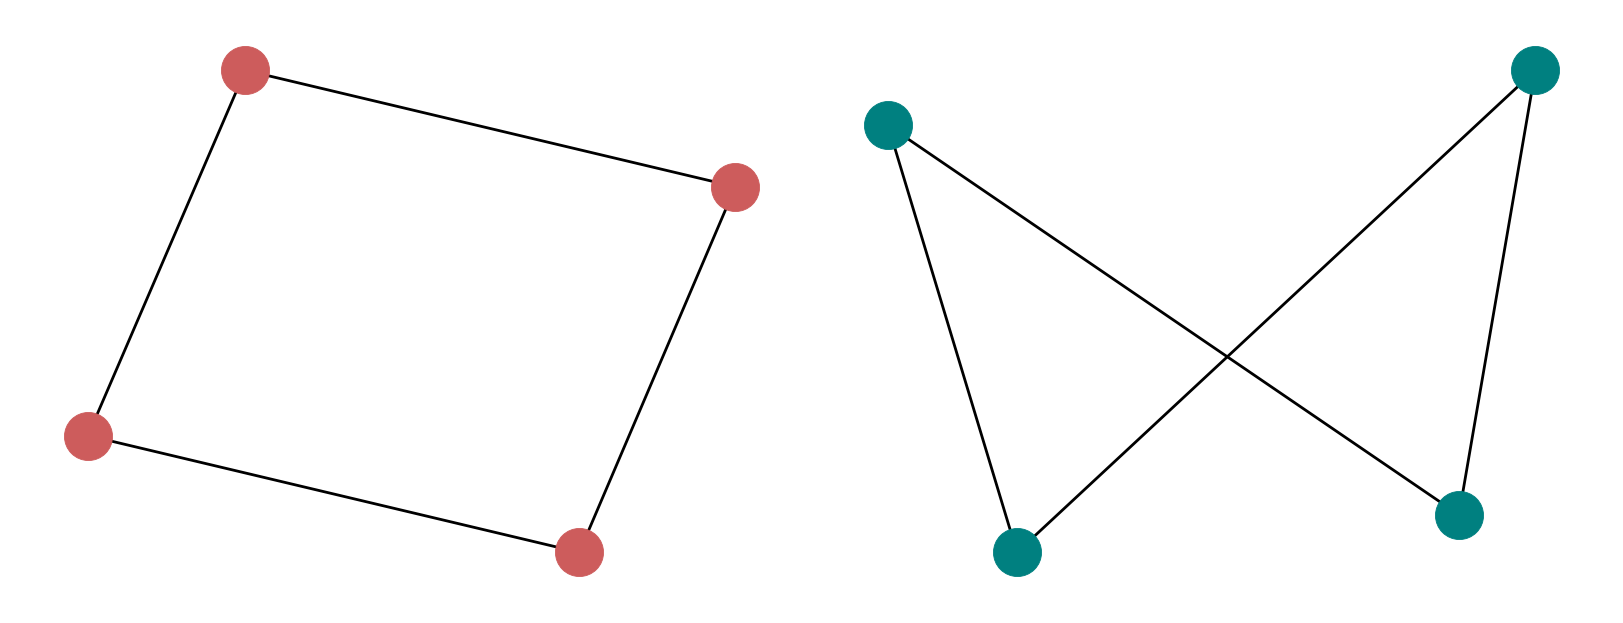

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
nx.draw(gm, ax=ax[0], pos=nx.spring_layout(gm, seed=0), node_color='indianred')
nx.draw(gm, ax=ax[1], pos=nx.spring_layout(gm, seed=10), node_color='teal')
plt.show()

### 1.2. Key vocabulary
- Adjacent: Two nodes are adjacent if there is an edge between them. They are also called neighbors.
- Degree: The degree of a node is how many edges touch it.
- Path: A path is a sequence of nodes connected by edges, like A-B-C.
- Cycle: A cycle is a path that starts and ends at the same node, like A-B-C-A.
- Connected graph: An undirected graph is connected if every node can reach every other node through some path. If not, it has connected components (separate *islands*).

### 1.3. Types of graphs
- Directed graph: edges have direction, for example: social networks follows.
- Weighted graph: edges have weights, for example: distances between cities.
- Bipartite graph: nodes can be divided into two sets, and edges only connect nodes from different sets, for example: users and the movies they rate.
- Tree: a special graph with no cycles, for example: family trees.

In [3]:
dg = nx.DiGraph()
dg.add_edge('A', 'B')

In [4]:
wg = nx.Graph()
wg.add_edge('A', 'B', weight=5)
wg.add_edge('B', 'C', weight=2)

In [5]:
students = ['S1', 'S2']
classes = ['Math', 'History']

bg = nx.Graph()
bg.add_nodes_from(students, bipartite=0)
bg.add_nodes_from(classes, bipartite=1)
bg.add_edges_from([('S1', 'Math'), ('S2', 'Math'), ('S2', 'History')])

### 1.4. Statistics
- Size: $|V|$ nodes, $|E|$ edges
- Density: how full the graph is (0 = sparse, 1 = complete)
- Degree summary: min/avg/max degree, top-degree nodes
- Connectivity: number of components, size of largest component

In [61]:
adj_matrix = np.array([
    [0, 1, 1, 1],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 0],
])

g = nx.from_numpy_array(adj_matrix)

In [ ]:
# g.number_of_edges()
# g.number_of_nodes()
# nx.density(g)
nx.is_connected(g)

True

In [75]:
degrees = dict(g.degree())
max_degree = max(degrees.values())
avg_degree = sum(degrees.values()) / len(degrees)

In [78]:
# handshake lemma
sum(degrees.values()) == 2 * g.number_of_edges()

True

:::{admonition} Case
:class: tip



:::

## 2. Graph algorithms

### 2.1. Graph traversal

### 2.2. Shortest path

### 2.3. Euler path

### 2.4. Hamilton path

### 2.5. Graph coloring

## 3. Network analysis

### 3.1. Centrality

### 3.2. Clustering

### 3.3. Community

## Resources
- googleapis.com - [Method for node ranking in a linked database](https://patentimages.storage.googleapis.com/37/a9/18/d7c46ea42c4b05/US6285999.pdf)
- googleapis.com - [Producing a ranking for pages using distances in a web-link graph](https://patentimages.storage.googleapis.com/b8/dc/3e/3b5b32f8acd264/US9165040.pdf)
- trenton3983.github.io - https://trenton3983.github.io/files/projects/2020-05-21_intro_to_network_analysis_in_python/2020-05-21_intro_to_network_analysis_in_python.html
- https://autogis-site.readthedocs.io/en/2020_/notebooks/L6/network-analysis.html